<a href="https://colab.research.google.com/github/abdullahalmohit/Phenotype-visualization/blob/main/Phenotypic_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shoot length (Anova + Tukey HSD)

Saving Shoot_length.csv to Shoot_length (2).csv
Original Data:
  Genotype     1     2     3   4     5
0       WT  28.0  41.0  32.0  34  19.0
1      TG1  29.0   8.0  28.5  47  33.0
2      TG2  45.5  39.0  40.0  40  38.0
3      TG3  34.0  46.0  32.0  34  36.5
4      TG4  34.5  21.5  30.5  26  40.0

Detected WIDE format → converting to LONG format...

Processed Data:
  Genotype Replicate  Shoot_Length
0       WT         1          28.0
1      TG1         1          29.0
2      TG2         1          45.5
3      TG3         1          34.0
4      TG4         1          34.5

===== Shapiro-Wilk Normality Test =====
WT: p = 0.9485
TG1: p = 0.6216
TG2: p = 0.0862
TG3: p = 0.0783
TG4: p = 0.9863
TG5: p = 0.9215

===== Levene Test (Homogeneity) =====
p = 0.4951

===== ANOVA RESULT =====
               sum_sq    df        F   PR(>F)
C(Genotype)   557.175   5.0  1.72411  0.16741
Residual     1551.200  24.0      NaN      NaN

===== TUKEY HSD =====
 Multiple Comparison of Means - Tukey HSD, FWER=0.

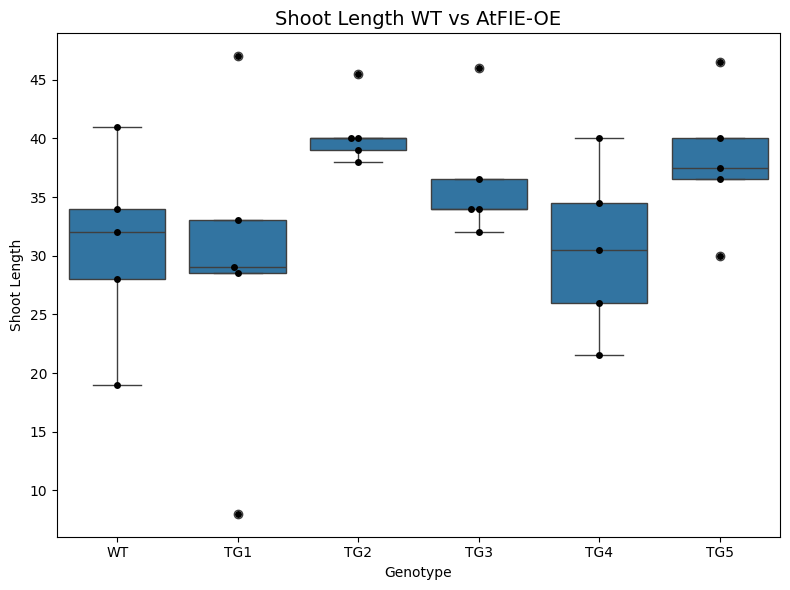

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================
# 1. Upload CSV
# ================================
from google.colab import files
uploaded = files.upload()

# ================================
# 2. Load data
# ================================
import pandas as pd

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Original Data:")
print(df.head())

# ================================
# 3. Convert to long format (auto-detect)
# ================================
if "Shoot_Length" not in df.columns:
    print("\nDetected WIDE format → converting to LONG format...")
    df_long = df.melt(id_vars="Genotype",
                      var_name="Replicate",
                      value_name="Shoot_Length")
else:
    print("\nDetected LONG format → using directly...")
    df_long = df.copy()

# Clean data
df_long["Shoot_Length"] = pd.to_numeric(df_long["Shoot_Length"], errors='coerce')
df_long = df_long.dropna()

print("\nProcessed Data:")
print(df_long.head())

# ================================
# 4. Assumption tests
# ================================
from scipy import stats

print("\n===== Shapiro-Wilk Normality Test =====")
for g in df_long["Genotype"].unique():
    p = stats.shapiro(df_long[df_long["Genotype"] == g]["Shoot_Length"])[1]
    print(f"{g}: p = {p:.4f}")

groups = [df_long[df_long["Genotype"] == g]["Shoot_Length"]
          for g in df_long["Genotype"].unique()]

p_levene = stats.levene(*groups)[1]
print(f"\n===== Levene Test (Homogeneity) =====")
print(f"p = {p_levene:.4f}")

# ================================
# 5. One-way ANOVA
# ================================
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Shoot_Length ~ C(Genotype)', data=df_long).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n===== ANOVA RESULT =====")
print(anova)

# ================================
# 6. Tukey HSD
# ================================
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df_long["Shoot_Length"], df_long["Genotype"])

print("\n===== TUKEY HSD =====")
print(tukey)

# Save Tukey results
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])
tukey_df.to_csv("tukey_results.csv", index=False)

# ================================
# 7. Summary stats (mean ± SD)
# ================================
summary = df_long.groupby("Genotype")["Shoot_Length"].agg(['mean','std'])
summary["mean_sd"] = summary["mean"].round(2).astype(str) + " ± " + summary["std"].round(2).astype(str)

print("\n===== Mean ± SD =====")
print(summary["mean_sd"])

summary.to_csv("summary_stats.csv")

# ================================
# 8. Visualization
# ================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x="Genotype", y="Shoot_Length", data=df_long)
sns.swarmplot(x="Genotype", y="Shoot_Length", data=df_long, color='black')

plt.title("Shoot Length WT vs AtFIE-OE", fontsize=14)
plt.xlabel("Genotype")
plt.ylabel("Shoot Length")

plt.tight_layout()
plt.savefig("shoot_length_plot.png", dpi=300)
plt.show()

# ================================
# 9. Download outputs
# ================================
files.download("shoot_length_plot.png")
files.download("tukey_results.csv")
files.download("summary_stats.csv")

Bolting

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bolting.csv to bolting.csv


In [ ]:
import pandas as pd

file_name = next(iter(uploaded))

# Skip bad header row and assign correct column names
df = pd.read_csv(file_name, skiprows=1)

# Manually set correct column names
df.columns = ["Days", "WT", "TG1", "TG2", "TG3", "TG4", "TG5"]

# Clean data
df = df.apply(pd.to_numeric, errors='coerce')

print(df.head())

   Days  WT  TG1  TG2  TG3  TG4  TG5
0    42   1    1    2    2    0    1
1    43   1    2    3    3    1    1
2    44   2    3    5    5    2    5
3    45   3    4    5    5    2    5
4    46   3    4    5    5    3    5


Convert cumulative counts → event data

In [ ]:
records = []

for genotype in df.columns[1:]:
    prev = 0
    plant_id = 1

    for i in range(len(df)):
        day = df.loc[i, "Days"]
        current = df.loc[i, genotype]

        if pd.isna(current):
            continue

        new_events = current - prev

        if new_events < 0:
            new_events = 0

        for _ in range(int(new_events)):
            records.append([genotype, plant_id, day, 1])
            plant_id += 1

        prev = current

event_df = pd.DataFrame(records, columns=["Genotype", "Plant", "Day", "Event"])

print(event_df.head())

  Genotype  Plant  Day  Event
0       WT      1   42      1
1       WT      2   44      1
2       WT      3   45      1
3       WT      4   48      1
4       WT      5   49      1


In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=d364b326eedac054060fe5481e8287dcd0674dbddd915a492fb3df158a97d21f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Kaplan–Meier plot

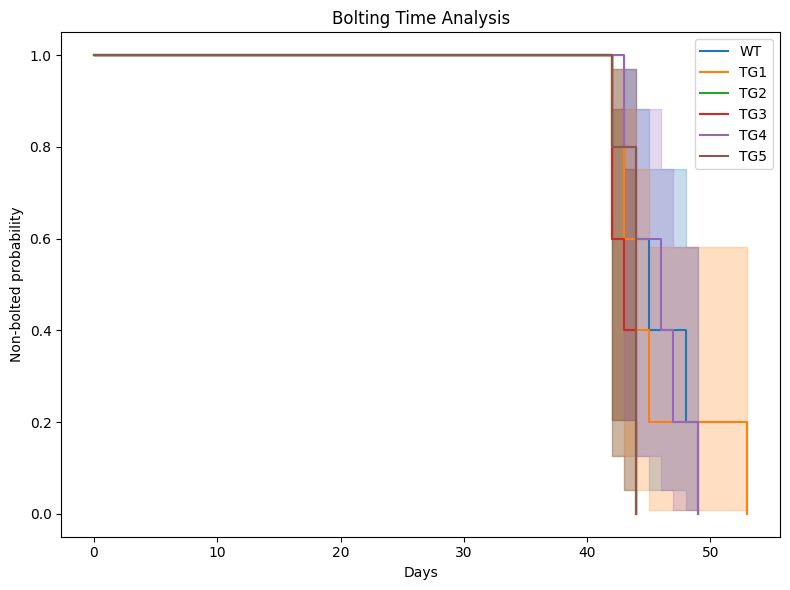

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

kmf = KaplanMeierFitter()

for g in event_df["Genotype"].unique():
    subset = event_df[event_df["Genotype"] == g]

    kmf.fit(durations=subset["Day"], event_observed=subset["Event"], label=g)
    kmf.plot_survival_function()

plt.title("Bolting Time Analysis")
plt.xlabel("Days")
plt.ylabel("Non-bolted probability")

plt.tight_layout()
plt.savefig("bolting_curve.png", dpi=300)
plt.show()

Log-rank test (WT vs all TGs)

In [ ]:
from lifelines.statistics import logrank_test

wt = event_df[event_df["Genotype"] == "WT"]

print("===== Log-rank Test (WT vs TGs) =====")

results = []

for g in event_df["Genotype"].unique():
    if g != "WT":
        tg = event_df[event_df["Genotype"] == g]

        result = logrank_test(
            wt["Day"], tg["Day"],
            event_observed_A=wt["Event"],
            event_observed_B=tg["Event"]
        )

        p = result.p_value
        print(f"WT vs {g}: p = {p:.4f}")

        results.append([g, p])

# Save results
res_df = pd.DataFrame(results, columns=["Comparison", "p-value"])
res_df.to_csv("logrank_results.csv", index=False)

===== Log-rank Test (WT vs TGs) =====
WT vs TG1: p = 0.9945
WT vs TG2: p = 0.0616
WT vs TG3: p = 0.0616
WT vs TG4: p = 0.9935
WT vs TG5: p = 0.1297


Median bolting time (T50)

In [ ]:
from lifelines import KaplanMeierFitter

print("\n===== Median Bolting Time (T50) =====")

kmf = KaplanMeierFitter()
t50_list = []

for g in event_df["Genotype"].unique():
    subset = event_df[event_df["Genotype"] == g]

    kmf.fit(subset["Day"], subset["Event"])
    median = kmf.median_survival_time_

    print(f"{g}: {median}")
    t50_list.append([g, median])

pd.DataFrame(t50_list, columns=["Genotype", "T50"]).to_csv("T50_values.csv", index=False)


===== Median Bolting Time (T50) =====
WT: 45.0
TG1: 44.0
TG2: 43.0
TG3: 43.0
TG4: 46.0
TG5: 44.0


In [ ]:
files.download("bolting_curve.png")
files.download("logrank_results.csv")
files.download("T50_values.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Flowring

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Flowring.csv to Flowring.csv


In [ ]:
import pandas as pd

file_name = next(iter(uploaded))

# Skip first broken title row
df = pd.read_csv(file_name, skiprows=1)

# Assign proper column names
df.columns = ["Days", "WT", "TG1", "TG2", "TG3", "TG4", "TG5"]

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print(df.head())

   Days  WT  TG1  TG2  TG3  TG4  TG5
0    42   0    0    0    0    0    0
1    43   0    0    0    2    0    2
2    44   0    1    3    3    0    4
3    45   1    2    4    3    0    4
4    46   1    3    4    3    1    5


Convert cumulative → individual flowering events

In [ ]:
records = []

for genotype in df.columns[1:]:
    prev = 0
    plant_id = 1

    for i in range(len(df)):
        day = df.loc[i, "Days"]
        current = df.loc[i, genotype]

        if pd.isna(current):
            continue

        new_events = current - prev

        if new_events < 0:
            new_events = 0

        for _ in range(int(new_events)):
            records.append([genotype, plant_id, day, 1])
            plant_id += 1

        prev = current

event_df = pd.DataFrame(records, columns=["Genotype", "Plant", "Day", "Event"])

print(event_df.head())

  Genotype  Plant  Day  Event
0       WT      1   45      1
1       WT      2   47      1
2       WT      3   50      1
3       WT      4   52      1
4       WT      5   53      1


Kaplan–Meier flowering curve

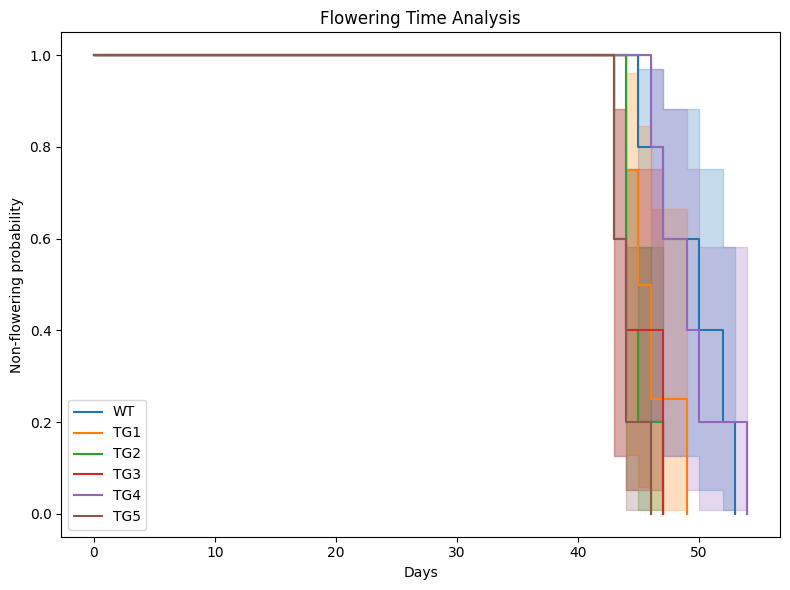

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

kmf = KaplanMeierFitter()

for g in event_df["Genotype"].unique():
    subset = event_df[event_df["Genotype"] == g]

    kmf.fit(subset["Day"], subset["Event"], label=g)
    kmf.plot_survival_function()

plt.title("Flowering Time Analysis")
plt.xlabel("Days")
plt.ylabel("Non-flowering probability")

plt.tight_layout()
plt.savefig("flowering_curve.png", dpi=300)
plt.show()

Log-rank test (WT vs TGs)

In [ ]:
from lifelines.statistics import logrank_test

wt = event_df[event_df["Genotype"] == "WT"]

print("===== Log-rank Test (WT vs TGs) =====")

results = []

for g in event_df["Genotype"].unique():
    if g != "WT":
        tg = event_df[event_df["Genotype"] == g]

        result = logrank_test(
            wt["Day"], tg["Day"],
            event_observed_A=wt["Event"],
            event_observed_B=tg["Event"]
        )

        p = result.p_value
        print(f"WT vs {g}: p = {p:.4f}")

        results.append([g, p])

pd.DataFrame(results, columns=["Comparison", "p-value"]).to_csv("flowering_logrank.csv", index=False)

===== Log-rank Test (WT vs TGs) =====
WT vs TG1: p = 0.0669
WT vs TG2: p = 0.0191
WT vs TG3: p = 0.0389
WT vs TG4: p = 0.8939
WT vs TG5: p = 0.0071


Median flowering time (T50)

In [ ]:
from lifelines import KaplanMeierFitter

print("\n===== Median Flowering Time (T50) =====")

kmf = KaplanMeierFitter()
t50_list = []

for g in event_df["Genotype"].unique():
    subset = event_df[event_df["Genotype"] == g]

    kmf.fit(subset["Day"], subset["Event"])
    median = kmf.median_survival_time_

    print(f"{g}: {median}")
    t50_list.append([g, median])

pd.DataFrame(t50_list, columns=["Genotype", "T50"]).to_csv("flowering_T50.csv", index=False)


===== Median Flowering Time (T50) =====
WT: 50.0
TG1: 45.0
TG2: 44.0
TG3: 44.0
TG4: 49.0
TG5: 44.0


In [ ]:
files.download("flowering_curve.png")
files.download("flowering_logrank.csv")
files.download("flowering_T50.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lateral branch

In [1]:
from google.colab import files
uploaded = files.upload()

Saving lateral_branch.csv to lateral_branch.csv


In [2]:
import pandas as pd

file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

# Clean column names
df.columns = df.columns.str.strip()

print(df.head())

  Genotype  1  2  3  4  5
0       WT  3  5  5  5  0
1      TG1  6  0  4  5  3
2      TG2  5  6  8  5  4
3      TG3  5  5  5  3  5
4      TG4  5  0  3  5  5


In [3]:
df_long = df.melt(id_vars="Genotype",
                  var_name="Replicate",
                  value_name="Branch_Number")

# Convert to numeric
df_long["Branch_Number"] = pd.to_numeric(df_long["Branch_Number"], errors='coerce')

# Drop missing
df_long = df_long.dropna()

print(df_long.head())

  Genotype Replicate  Branch_Number
0       WT         1              3
1      TG1         1              6
2      TG2         1              5
3      TG3         1              5
4      TG4         1              5


Assumption testing

In [4]:
from scipy import stats

print("Shapiro-Wilk Test:")
for g in df_long["Genotype"].unique():
    p = stats.shapiro(df_long[df_long["Genotype"] == g]["Branch_Number"])[1]
    print(f"{g}: p = {p:.4f}")

groups = [df_long[df_long["Genotype"] == g]["Branch_Number"]
          for g in df_long["Genotype"].unique()]

p_levene = stats.levene(*groups)[1]
print(f"\nLevene test p = {p_levene:.4f}")

Shapiro-Wilk Test:
WT: p = 0.0327
TG1: p = 0.6853
TG2: p = 0.4925
TG3: p = 0.0001
TG4: p = 0.0327
TG5: p = 0.0065

Levene test p = 0.7174


One-way ANOVA

In [5]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Branch_Number ~ C(Genotype)', data=df_long).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\nANOVA result:")
print(anova)


ANOVA result:
                sum_sq    df         F    PR(>F)
C(Genotype)  16.666667   5.0  1.092896  0.389794
Residual     73.200000  24.0       NaN       NaN


Tukey HSD

In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df_long["Branch_Number"], df_long["Genotype"])
print(tukey)

# Save results
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])
tukey_df.to_csv("branch_tukey.csv", index=False)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   TG1    TG2      2.0 0.4779 -1.4151 5.4151  False
   TG1    TG3      1.0 0.9413 -2.4151 4.4151  False
   TG1    TG4      0.0    1.0 -3.4151 3.4151  False
   TG1    TG5      1.0 0.9413 -2.4151 4.4151  False
   TG1     WT      0.0    1.0 -3.4151 3.4151  False
   TG2    TG3     -1.0 0.9413 -4.4151 2.4151  False
   TG2    TG4     -2.0 0.4779 -5.4151 1.4151  False
   TG2    TG5     -1.0 0.9413 -4.4151 2.4151  False
   TG2     WT     -2.0 0.4779 -5.4151 1.4151  False
   TG3    TG4     -1.0 0.9413 -4.4151 2.4151  False
   TG3    TG5      0.0    1.0 -3.4151 3.4151  False
   TG3     WT     -1.0 0.9413 -4.4151 2.4151  False
   TG4    TG5      1.0 0.9413 -2.4151 4.4151  False
   TG4     WT      0.0    1.0 -3.4151 3.4151  False
   TG5     WT     -1.0 0.9413 -4.4151 2.4151  False
---------------------------------------------------


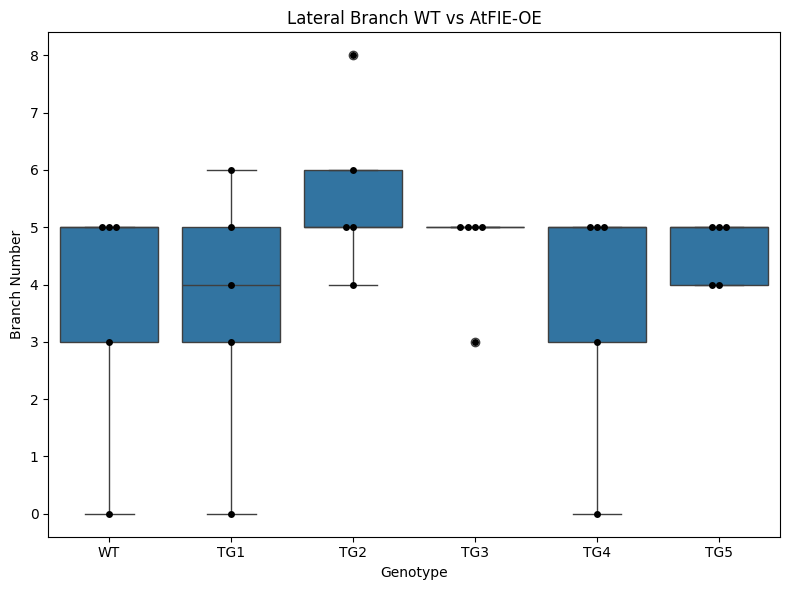

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x="Genotype", y="Branch_Number", data=df_long)
sns.swarmplot(x="Genotype", y="Branch_Number", data=df_long, color='black')

plt.title("Lateral Branch WT vs AtFIE-OE")
plt.xlabel("Genotype")
plt.ylabel("Branch Number")

plt.tight_layout()
plt.savefig("branch_plot.png", dpi=300)
plt.show()

In [9]:
summary = df_long.groupby("Genotype")["Branch_Number"].agg(['mean','std'])

summary["mean_sd"] = summary["mean"].round(2).astype(str) + " ± " + summary["std"].round(2).astype(str)

print("\nMean ± SD:")
print(summary["mean_sd"])

summary.to_csv("branch_summary.csv")


Mean ± SD:
Genotype
TG1     3.6 ± 2.3
TG2    5.6 ± 1.52
TG3    4.6 ± 0.89
TG4    3.6 ± 2.19
TG5    4.6 ± 0.55
WT     3.6 ± 2.19
Name: mean_sd, dtype: object


In [10]:
files.download("branch_plot.png")
files.download("branch_tukey.csv")
files.download("branch_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Silique counting

In [11]:
from google.colab import files
uploaded = files.upload()

Saving Silique counting.csv to Silique counting.csv


In [12]:
import pandas as pd

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

# Clean column names
df.columns = df.columns.str.strip()

# Fix duplicate column (TG5(4) repeated)
df = df.loc[:, ~df.columns.duplicated()]

print(df.head())

   Days  WT1  WT2  WT3  WT4  WT5  TG1(1)  TG1(2)  TG1(3)  TG1(4)  ...  TG4(1)  \
0    55    0    0    1    5    2       0       0       0       6  ...       0   
1    56    0    2    4    6    6       0       0       0      10  ...       0   
2    57    0    3    4    9    0       0       0       0      23  ...       1   
3    58    1    6    7   12    0       0       0       2      32  ...       1   
4    59    1   12    8   13    1       1       0       2      36  ...       1   

   TG4(2)  TG4(3)  TG4(4)  TG4(5)  TG5(1)  TG5(2)  TG5(3)  TG5(4)  TG5(4).1  
0       0       0       4       2       3       7       9       2        10  
1       0       0       5       6       5       9       9       4        10  
2       0       0       8      10       8      11      10       6        17  
3       0       0      12      16       8      12      10      19        27  
4       1       1      13      22       9      18      11      12        34  

[5 rows x 31 columns]


In [13]:
df_long = df.melt(id_vars="Days", var_name="Sample", value_name="Silique")

# Extract genotype (WT, TG1...)
df_long["Genotype"] = df_long["Sample"].str.extract(r'(WT|TG\d+)')

# Extract replicate number
df_long["Replicate"] = df_long["Sample"].str.extract(r'\(?(\d+)\)?')

# Clean
df_long["Silique"] = pd.to_numeric(df_long["Silique"], errors='coerce')
df_long = df_long.dropna()

print(df_long.head())

   Days Sample  Silique Genotype Replicate
0    55    WT1        0       WT         1
1    56    WT1        0       WT         1
2    57    WT1        0       WT         1
3    58    WT1        1       WT         1
4    59    WT1        1       WT         1


Mixed Effects Model (KEY ANALYSIS)

In [14]:
import statsmodels.formula.api as smf

# Mixed model: Silique ~ Genotype + Days + interaction
model = smf.mixedlm(
    "Silique ~ Genotype * Days",
    df_long,
    groups=df_long["Replicate"]
)

result = model.fit()

print(result.summary())

                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     Silique  
No. Observations:       210         Method:                 REML     
No. Groups:             5           Scale:                  98.4414  
Min. group size:        42          Log-Likelihood:         -762.5960
Max. group size:        42          Converged:              Yes      
Mean group size:        42.0                                         
---------------------------------------------------------------------
                      Coef.   Std.Err.   z    P>|z|  [0.025   0.975] 
---------------------------------------------------------------------
Intercept            -136.126   48.813 -2.789 0.005 -231.797  -40.454
Genotype[T.TG2]       -75.463   69.025 -1.093 0.274 -210.750   59.823
Genotype[T.TG3]      -257.182   68.970 -3.729 0.000 -392.362 -122.003
Genotype[T.TG4]         8.363   69.051  0.121 0.904 -126.975  143.700
Genotype[T.TG5]       -86.789   68.9

Mean ± SD over time

In [15]:
summary = df_long.groupby(["Days","Genotype"])["Silique"].agg(['mean','std']).reset_index()
print(summary.head())

   Days Genotype  mean       std
0    55      TG1   2.6  3.577709
1    55      TG2   6.2  3.962323
2    55      TG3   5.2  4.207137
3    55      TG4   1.2  1.788854
4    55      TG5   6.2  3.563706


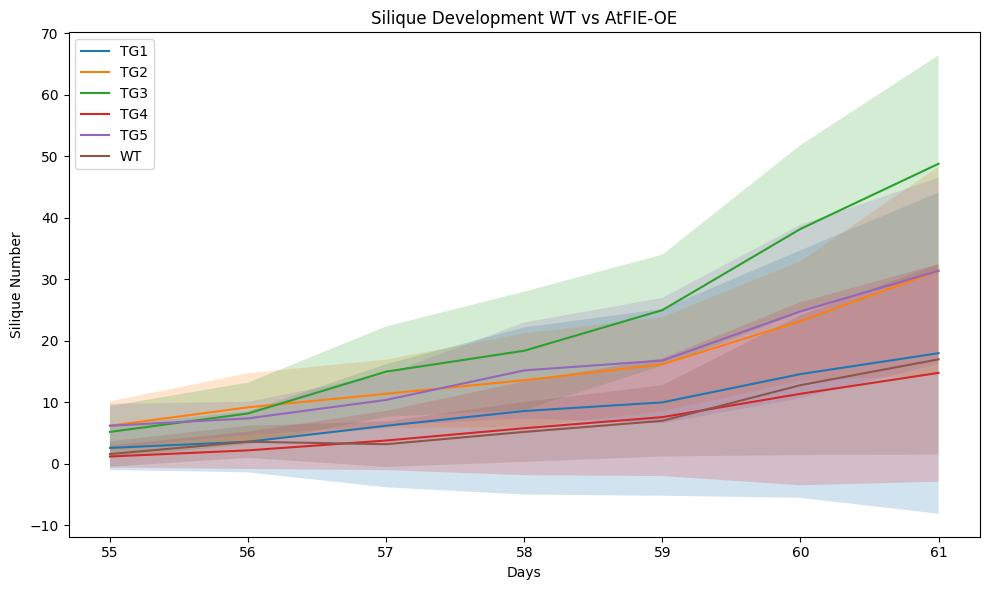

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for g in summary["Genotype"].unique():
    subset = summary[summary["Genotype"] == g]

    plt.plot(subset["Days"], subset["mean"], label=g)
    plt.fill_between(
        subset["Days"],
        subset["mean"] - subset["std"],
        subset["mean"] + subset["std"],
        alpha=0.2
    )

plt.xlabel("Days")
plt.ylabel("Silique Number")
plt.title("Silique Development WT vs AtFIE-OE")

plt.legend()
plt.tight_layout()

plt.savefig("silique_growth_curve.png", dpi=300)
plt.show()

In [17]:
summary.to_csv("silique_summary.csv", index=False)

from google.colab import files
files.download("silique_summary.csv")
files.download("silique_growth_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

seed germination

In [19]:
from google.colab import files
uploaded = files.upload()

Saving seed germination.csv to seed germination.csv


In [20]:
import pandas as pd

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

# Clean column names
df.columns = df.columns.str.strip()

# Separate total seeds row
total_row = df[df["days"] == "total seeds"]
df = df[df["days"] != "total seeds"]

# Convert to numeric
df["days"] = pd.to_numeric(df["days"])
df = df.apply(pd.to_numeric, errors='coerce')

print(df.head())

   days  WT  TG1  TG2  TG3  TG4  TG5
0     3  45   46    8   44   47   51
1     4  52   57    8   53   50   62
2     5  52   60   10   58   52   67
3     6  60   68   12   63   56   71
4     7  66   71   12   65   58   77


Convert cumulative → germination events

In [21]:
records = []

for genotype in df.columns[1:]:
    prev = 0
    seed_id = 1

    for i in range(len(df)):
        day = df.loc[i, "days"]
        current = df.loc[i, genotype]

        new_events = current - prev

        if new_events < 0:
            new_events = 0

        for _ in range(int(new_events)):
            records.append([genotype, seed_id, day, 1])
            seed_id += 1

        prev = current

event_df = pd.DataFrame(records, columns=["Genotype","Seed","Day","Event"])
print(event_df.head())

  Genotype  Seed  Day  Event
0       WT     1    3      1
1       WT     2    3      1
2       WT     3    3      1
3       WT     4    3      1
4       WT     5    3      1


In [22]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8bd8d37c2698d71d1c770bc53d654f8e5e8a6984a795964c682d3e5a0e0644ba
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Kaplan–Meier germination curve

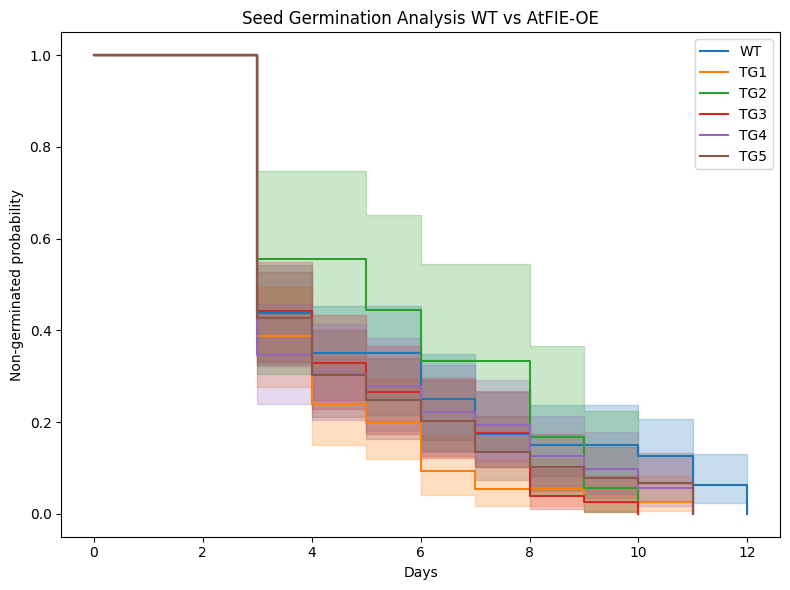

In [29]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

kmf = KaplanMeierFitter()

for g in event_df["Genotype"].unique():
    sub = event_df[event_df["Genotype"] == g]

    kmf.fit(sub["Day"], sub["Event"], label=g)
    kmf.plot_survival_function()

plt.xlabel("Days")
plt.ylabel("Non-germinated probability")
plt.title("Seed Germination Analysis WT vs AtFIE-OE")

plt.tight_layout()
plt.savefig("germination_curve.png", dpi=300)
plt.show()

Log-rank test (WT vs TGs)

In [24]:
from lifelines.statistics import logrank_test

wt = event_df[event_df["Genotype"] == "WT"]

print("===== Log-rank Test =====")

for g in event_df["Genotype"].unique():
    if g != "WT":
        tg = event_df[event_df["Genotype"] == g]

        p = logrank_test(
            wt["Day"], tg["Day"],
            event_observed_A=wt["Event"],
            event_observed_B=tg["Event"]
        ).p_value

        print(f"WT vs {g}: p = {p:.4f}")

===== Log-rank Test =====
WT vs TG1: p = 0.0080
WT vs TG2: p = 0.8788
WT vs TG3: p = 0.0779
WT vs TG4: p = 0.1643
WT vs TG5: p = 0.1248


T50 (median germination time)

In [25]:
from lifelines import KaplanMeierFitter

print("\n===== T50 =====")

kmf = KaplanMeierFitter()

for g in event_df["Genotype"].unique():
    sub = event_df[event_df["Genotype"] == g]
    kmf.fit(sub["Day"], sub["Event"])

    print(f"{g}: {kmf.median_survival_time_}")


===== T50 =====
WT: 3.0
TG1: 3.0
TG2: 5.0
TG3: 3.0
TG4: 3.0
TG5: 3.0


Germination rate (slope)

In [26]:
import numpy as np

slopes = []

for g in df.columns[1:]:
    slope = np.polyfit(df["days"], df[g], 1)[0]
    slopes.append([g, slope])

slope_df = pd.DataFrame(slopes, columns=["Genotype","Rate"])
print(slope_df)

  Genotype      Rate
0       WT  3.587879
1      TG1  2.830303
2      TG2  1.321212
3      TG3  3.969697
4      TG4  2.975758
5      TG5  3.921212


Final germination (%) comparison

In [27]:
# Extract totals
totals = total_row.iloc[0, 1:]

final = df.iloc[-1, 1:]

germ_percent = (final / totals) * 100

germ_df = pd.DataFrame({
    "Genotype": germ_percent.index,
    "Germination_%": germ_percent.values
})

print(germ_df)

  Genotype Germination_%
0       WT     91.954023
1      TG1     90.361446
2      TG2         100.0
3      TG3         98.75
4      TG4     88.888889
5      TG5      96.73913


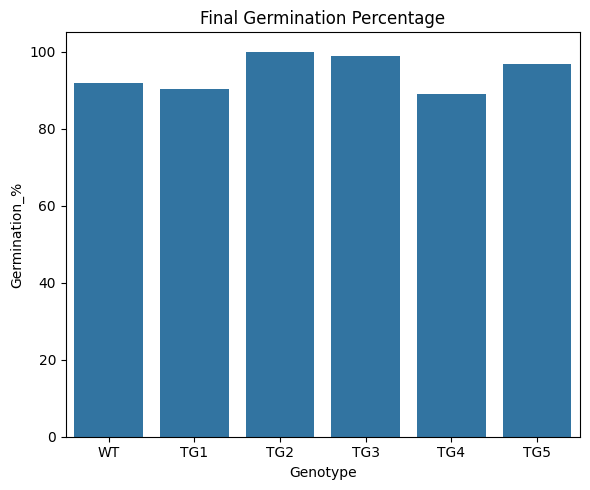

In [28]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.barplot(x="Genotype", y="Germination_%", data=germ_df)

plt.title("Final Germination Percentage")
plt.tight_layout()
plt.savefig("germination_percent.png", dpi=300)
plt.show()

In [30]:
files.download("germination_curve.png")
files.download("germination_percent.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>